In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np

In [2]:
import nltk
import re
from nltk.tokenize import word_tokenize

In [3]:
from matplotlib import pyplot as plt
import seaborn as sns

In [39]:
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

In [5]:
from tqdm.notebook import tqdm

In [7]:
from torchtext.vocab import build_vocab_from_iterator

In [8]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.manual_seed(SEED)
g = torch.Generator()
g.manual_seed(SEED)

In [9]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [10]:
train_df = pd.read_csv('data/train_balanced.csv') 
val_df = pd.read_csv('data/validation_df.csv')
test_df = pd.read_csv('data/test_df.csv')

In [11]:
label_map = {'bad': 0, 'neutral': 1, 'good': 2}

In [12]:
train_df['Label'] = train_df['Score'].map(label_map)
val_df['Label'] = val_df['Score'].map(label_map)
test_df['Label'] = test_df['Score'].map(label_map)

In [49]:
#train_df.head()

Pre-trained GloVe vectors ([glove.6B.300d.txt](https://www.kaggle.com/datasets/thanakomsn/glove6b300dtxt)) were loaded into a Python dictionary. This allows the model to use rich semantic representations learned from a massive external text corpus, helping it understand word meanings right from the start.

In [14]:
word_embeddings = {}
with open('glove.6B.300d.txt', 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        word_embeddings[word] = coefs

Text was cleaned by converting everything to lowercase, removing HTML tags and URLs, and filtering out punctuation to keep only meaningful words and numbers.

In [15]:
def clean_and_tokenize(text):
    text = str(text).lower()
    
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word.isalnum()]
    
    return tokens

In [70]:
tokenized_train = [clean_and_tokenize(t) for t in train_df['Text']]
tokenized_valid   = [clean_and_tokenize(t) for t in val_df['Text']]
tokenized_test  = [clean_and_tokenize(t) for t in test_df['Text']]

In [71]:
PAD_TOKEN = '<pad>'
UNK_TOKEN = '<unk>'

In [72]:
vocab = build_vocab_from_iterator(tokenized_train,min_freq=10,specials=[PAD_TOKEN,UNK_TOKEN],special_first=True)

In [73]:
vocab.set_default_index(vocab[UNK_TOKEN])

In [74]:
print('Vocabulary size:', len(vocab))

Vocabulary size: 4845


In [75]:
class TextDataset(Dataset):
    def __init__(self, tokenized_texts, labels, vocab, max_len=50):
        
        processed_indices = []
        for tokens in tokenized_texts:
            indices = [vocab[w] for w in tokens]
            indices = indices[:max_len] + [0] * max(0, max_len - len(indices))
            
            processed_indices.append(indices)
            
        self.texts = torch.tensor(processed_indices, dtype=torch.long)
        self.labels = torch.tensor(labels.values, dtype=torch.long)
        
    def __len__(self):
        return len(self.texts)
        
    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

In [76]:
MAX_LEN = 50
BATCH_SIZE = 128

In [77]:
train_dataset = TextDataset(tokenized_train, train_df['Label'], vocab, max_len=MAX_LEN)
val_dataset = TextDataset(tokenized_valid, val_df['Label'], vocab, max_len=MAX_LEN)
test_dataset = TextDataset(tokenized_test, test_df['Label'], vocab, max_len=MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,generator=g)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [78]:
EMBEDDING_DIM = 300

In [79]:
vocab_size = len(vocab)

In [80]:
embedding_matrix = torch.zeros((vocab_size, EMBEDDING_DIM))
unmached_words = []
matched_words = 0
for word, idx in vocab.get_stoi().items():
    if word == PAD_TOKEN or word == UNK_TOKEN:
        continue
    vector = word_embeddings.get(word)
    if vector is not None:
        embedding_matrix[idx] = torch.tensor(vector)
        matched_words += 1
    else:
        unmached_words.append(word)

In [27]:
print('Number of unmached words: ',len(unmached_words),'number of mached words: ',matched_words)

Number of unmached words:  95 number of mached words:  4748


In [70]:
print(unmached_words[:20])

['ziplock', 'vitacoco', 'soooooo', 'shirataki', 'flavvors', 'convience', 'alittle', '0z', 'tasteing', 'snickerdoodle', 'decaffinated', 'delicous', 'chocolately', 'blackcurrent', 'blackcurrat', 'teavana', 'realllly', 'ntilde', 'kurig', 'pkgs']


Words missing from our vocabulary primarily consist of brand names, intentional typos, and common spelling errors, which aligns with the typical noise found in product reviews.

Bidirectional LSTM classifier that utilizes pre-trained embeddings

In [20]:
class SentimentLSTM(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, output_dim, n_layers,dropout):
        super().__init__()
        vocab_size, embedding_dim = embedding_matrix.shape
        
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix,freeze=True,padding_idx=0)
        
        
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=n_layers, batch_first=True, bidirectional=True)
        
        self.dropout = nn.Dropout(0.2)
        # *2 jer je bidirekcioni
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        
    def forward(self, text):
        embedded = self.embedding(text)
        output, (hidden, cell) = self.lstm(embedded)

        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]
        
        x = torch.cat((forward_hidden, backward_hidden), dim=1)
        
        x = self.dropout(x)
        return self.fc(x)

In [21]:
def train_model(model, optimizer,scheduler, train_loader, valid_loader, epochs=5,save_path='models/best_LSTM.pth',criterion=None):    
    model.to(device)

    if criterion is None:
        criterion = nn.CrossEntropyLoss()

    metrics = {
        'train_loss': [],
        'train_accuracy': [],
        'train_f1' : [],
        'train_steps': [],
        'valid_loss': [],
        'valid_accuracy': [],
        'valid_f1': [],
        'valid_steps': [],
    }

    step = 0
    best_val_f1 = 0.0

    
    for epoch in range(epochs):
        model.train()
        train_loss_epoch = 0
        train_correct = 0
        train_samples = 0
        train_preds = []
        train_labels = []
        
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            inputs, labels = inputs.to(device), labels.to(device)
            batch_size = labels.size(0)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            _, predicted = torch.max(outputs, 1)
            correct = (predicted == labels).sum().item()
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            metrics['train_loss'].append(loss.item())
            metrics['train_accuracy'].append(correct / batch_size)
            metrics['train_steps'].append(step)

    
            train_loss_epoch += loss.item() * batch_size
            train_correct += correct
            train_samples += batch_size

            train_preds.extend(predicted.cpu().numpy())
            train_labels.extend(labels.cpu().numpy())

            step += 1
            
        
        train_loss = train_loss_epoch / train_samples
        train_accuracy = train_correct / train_samples
        train_f1 = f1_score(train_labels, train_preds, average='macro')
        
        metrics['train_f1'].append(train_f1)
            
        model.eval()
        with torch.no_grad():
            valid_loss_total = 0
            valid_correct = 0
            valid_samples = 0
            val_preds = []
            val_labels = []
            
            for inputs, labels in tqdm(valid_loader, desc=f"Epoha {epoch+1}/{epochs} [Valid]"):
                inputs, labels = inputs.to(device), labels.to(device)
                batch_size = labels.size(0)
            
                outputs = model(inputs)
                loss = nn.CrossEntropyLoss(reduction='sum')(outputs, labels)
                
                _, predicted = torch.max(outputs, 1)
                correct = (predicted == labels).sum().item()
                
                valid_loss_total += loss.item()
                valid_correct += correct
                valid_samples += batch_size
                
                val_preds.extend(predicted.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

            valid_loss = valid_loss_total / valid_samples
            valid_accuracy = valid_correct / valid_samples
            valid_f1 = f1_score(val_labels, val_preds, average='macro')

            scheduler.step(valid_f1)
            
            if valid_f1 > best_val_f1:
                best_val_f1 = valid_f1
    
                torch.save(model.state_dict(), save_path)
                
            metrics['valid_loss'].append(valid_loss)
            metrics['valid_accuracy'].append(valid_accuracy)
            metrics['valid_f1'].append(valid_f1)
            metrics['valid_steps'].append(step)

        
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} - Train Acc: {train_accuracy:.4f} | Val Loss: {valid_loss:.4f} - Val Acc: {valid_accuracy:.4f} - Val F1 (Macro): {valid_f1:.4f}")
        
    return metrics

In [22]:
def plot_all_metrics(metrics,save_path):
    epochs = range(1, len(metrics['valid_loss']) + 1)

    plt.figure(figsize=(18, 5))
    
    # Loss plot
    plt.subplot(1, 3, 1)
    plt.plot(metrics['train_steps'], metrics['train_loss'], label='Train Loss (per batch)', color='blue', alpha=0.3)
    plt.plot(metrics['valid_steps'], metrics['valid_loss'], label='Validation Loss', color='orange', marker='s', linewidth=2)
    plt.xlabel('Training Steps')
    plt.ylabel('Loss')
    plt.title('Loss Curves (Steps)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # 2. Accuracy plot
    plt.subplot(1, 3, 2)
    plt.plot(metrics['train_steps'], metrics['train_accuracy'], label='Train Accuracy (per batch)', color='blue', alpha=0.3)
    plt.plot(metrics['valid_steps'], metrics['valid_accuracy'], label='Validation Accuracy', color='purple', marker='s', linewidth=2)
    plt.xlabel('Training Steps')
    plt.ylabel('Accuracy')
    plt.title('Accuracy Curves')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # 3. F1-Score Plot
    plt.subplot(1, 3, 3)
    plt.plot(epochs, metrics['train_f1'], 'o-', label='Train F1 (Macro)', color='blue')
    plt.plot(epochs, metrics['valid_f1'] if 'valid_f1' in metrics else metrics.get('valid_accuracy'), 's-', label='Val F1 (Macro)', color='green', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('F1 Score')
    plt.title('Macro F1-Score Across Epochs')
    plt.xticks(epochs)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

In [61]:
def evaluate_and_plot_confusion_matrix(model, valid_loader,model_path,save_path):
    
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    class_names = ['Bad', 'Neutral', 'Good']
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in valid_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()

    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    
    print('\nClassification Report:')
    print(classification_report(all_labels, all_preds, target_names=class_names))
    report_dict = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    return report_dict

# Experiment 1: Training on a balanced dataset

In [ ]:
vocab_size = len(vocab)  
EMBEDDING_DIM = 300      
HIDDEN_DIM = 128         
OUTPUT_DIM = 3           
N_LAYERS = 2 
DROPOUT = 0.2
model = SentimentLSTM(embedding_matrix,HIDDEN_DIM,OUTPUT_DIM,N_LAYERS,DROPOUT)

optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=1)

metrics = train_model(
    model=model, 
    optimizer=optimizer,
    scheduler = scheduler,
    train_loader=train_loader,  
    valid_loader=val_loader,  
    epochs=20,
    save_path='models/best_LSTM_v1.pth'
)

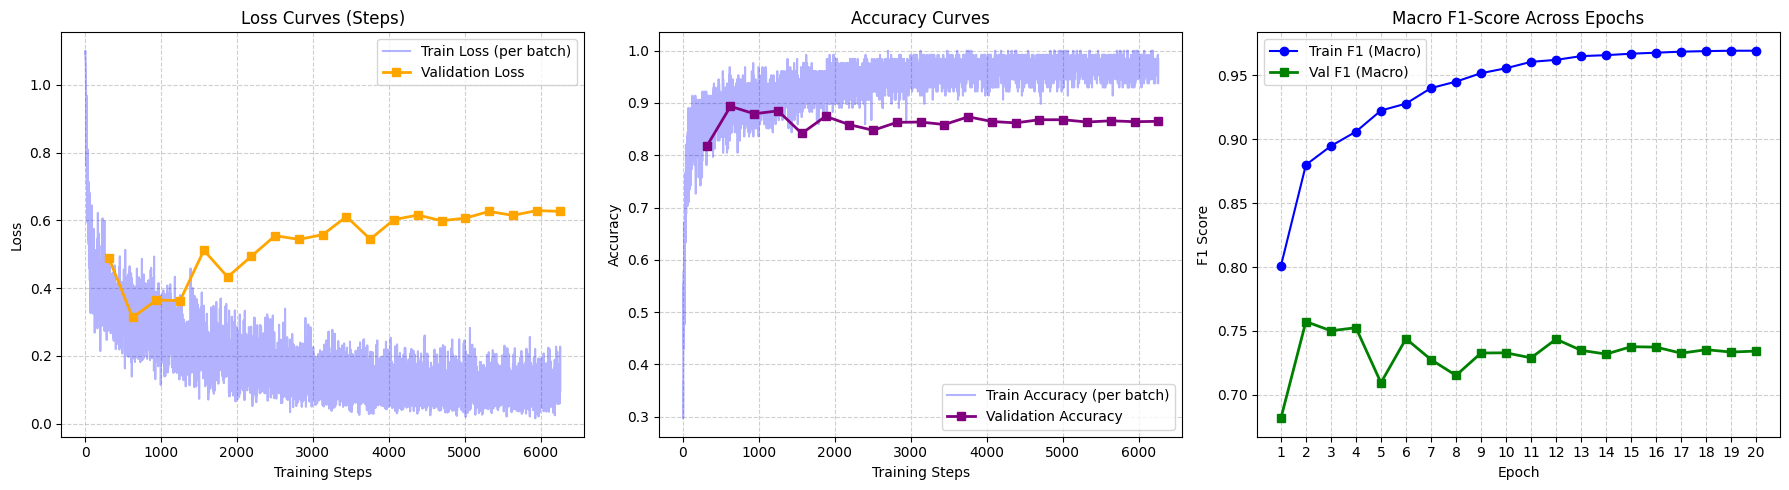

In [64]:
plot_all_metrics(metrics,'plots/LSTM_v1_training_metrics.png')

Based on the image, it was observed that after the second epoch the model began to overfit, as the training loss decreased while the validation loss increased. Similarly accuracy steadily increased on the training set, whereas on the validation set it dropped and then stagnated, the same applies to the F1-score. Based on this the model obtained at the end of the second epoch was saved and attempt to improve it by strengthening regularization.

In [ ]:
vocab_size = len(vocab)  
EMBEDDING_DIM = 300      
HIDDEN_DIM = 128         
OUTPUT_DIM = 3           
N_LAYERS = 2 
DROPOUT = 0.5
num_epochs = 10

model2 = SentimentLSTM(embedding_matrix,HIDDEN_DIM,OUTPUT_DIM,N_LAYERS,DROPOUT)
model2.load_state_dict(torch.load('models/best_LSTM_v1.pth', map_location=device))
model2.to(device)

optimizer2 = optim.Adam(model2.parameters(), lr=0.0005)
scheduler2 = optim.lr_scheduler.ReduceLROnPlateau(optimizer2, mode='max', factor=0.5, patience=2)

metrics_2 = train_model(
    model=model2, 
    optimizer=optimizer2,
    scheduler = scheduler2,
    train_loader=train_loader,  
    valid_loader=val_loader,  
    epochs=num_epochs,
    save_path='models/best_LSTM_v2.pth'
)

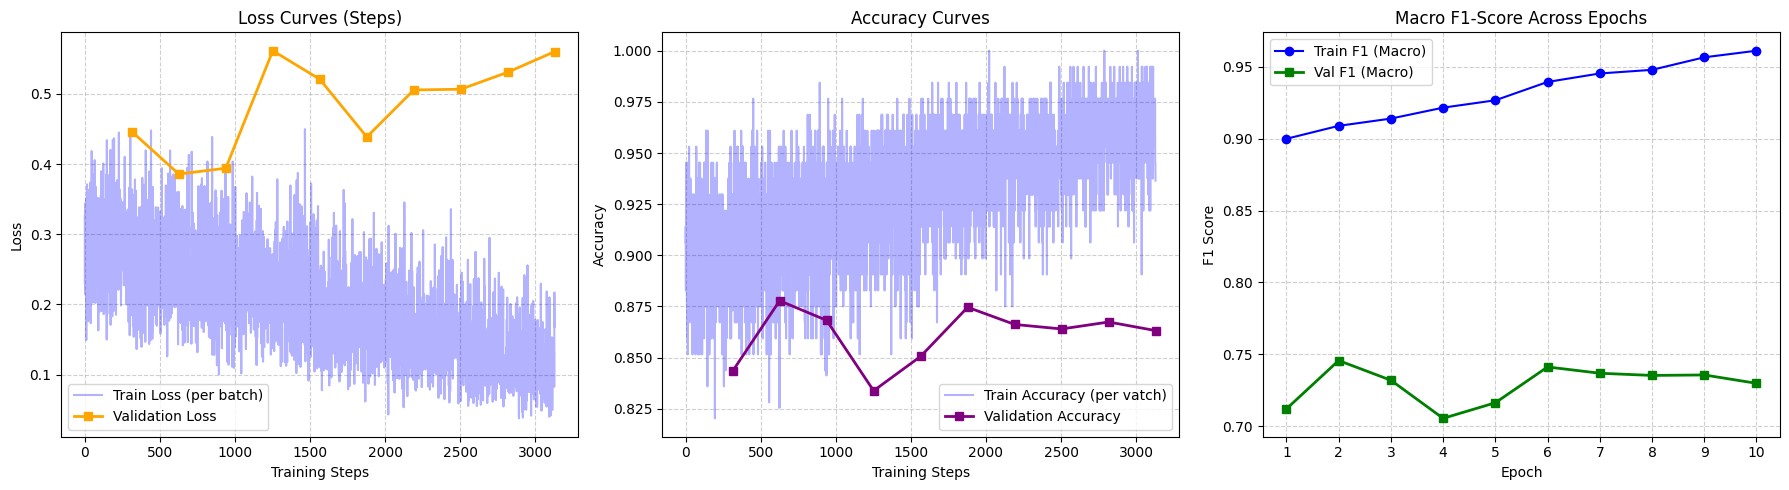

In [61]:
plot_all_metrics(metrics_2,'plots/LSTM_v2_training_metrics.png')

After increasing dropout and reducing the learning rate on pretrained model (v1) the model failed to achieve better results. Based on the image, it was observed that the loss continued to decrease for the training set but not for the validation set, and both accuracy and F1-score increased only for the training set. Therefore, this attempt was discarded and decision was made to try with even stronger regularization on pretrainded model(v1).

In [65]:
vocab_size = len(vocab)  
EMBEDDING_DIM = 300      
HIDDEN_DIM = 128         
OUTPUT_DIM = 3           
N_LAYERS = 2 
DROPOUT = 0.5
num_epochs = 10

model3 = SentimentLSTM(embedding_matrix,HIDDEN_DIM,OUTPUT_DIM,N_LAYERS,DROPOUT)
model3.load_state_dict(torch.load('models/best_LSTM_v1.pth', map_location=device))
model3.to(device)

optimizer3 = optim.Adam(model3.parameters(), lr=0.0005,weight_decay=1e-4)
scheduler3 = optim.lr_scheduler.ReduceLROnPlateau(optimizer3, mode='max', factor=0.5, patience=2)

metrics_3 = train_model(
    model=model3, 
    optimizer=optimizer3,
    scheduler = scheduler3,
    train_loader=train_loader,  
    valid_loader=val_loader,  
    epochs=num_epochs,
    save_path='models/best_LSTM_v3.pth'
)

Epoch 1/10 [Train]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoha 1/10 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [1/10] | Train Loss: 0.2850 - Train Acc: 0.8979 | Val Loss: 0.3833 - Val Acc: 0.8714 - Val F1 (Macro): 0.7413


Epoch 2/10 [Train]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoha 2/10 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

...

Epoha 9/10 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [9/10] | Train Loss: 0.1706 - Train Acc: 0.9424 | Val Loss: 0.5439 - Val Acc: 0.8462 - Val F1 (Macro): 0.7188


Epoch 10/10 [Train]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoha 10/10 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [10/10] | Train Loss: 0.1624 - Train Acc: 0.9466 | Val Loss: 0.5198 - Val Acc: 0.8630 - Val F1 (Macro): 0.7323


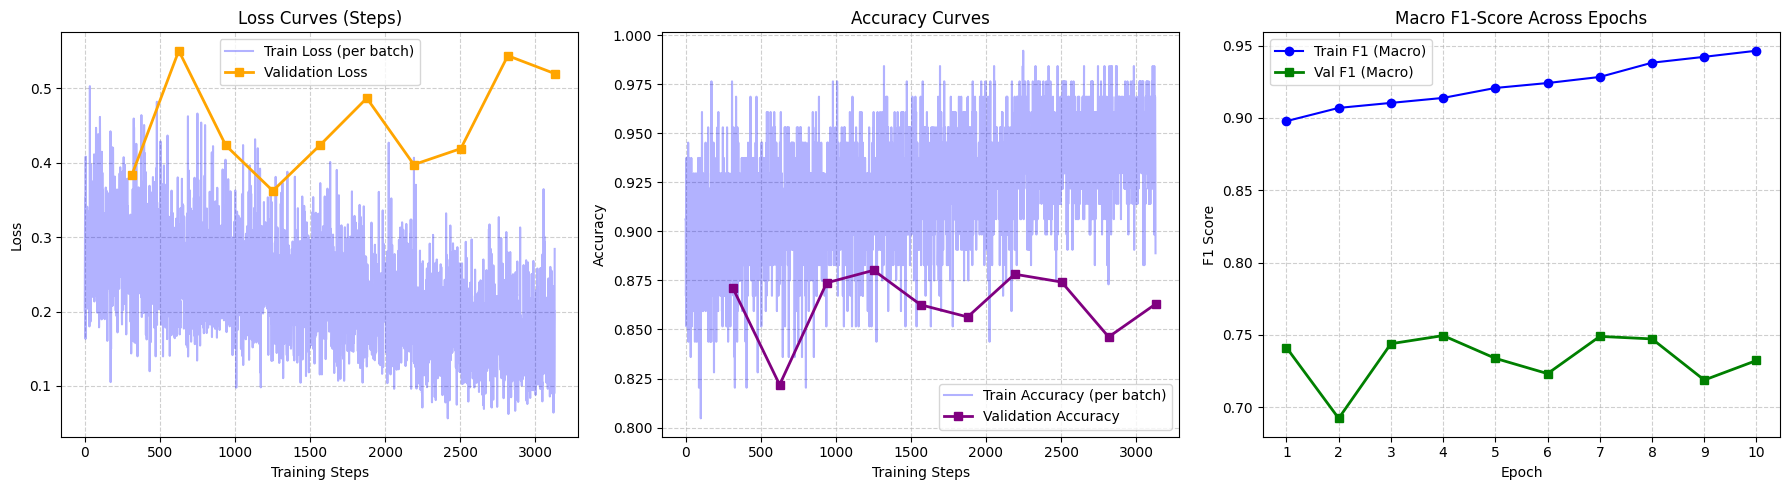

In [67]:
plot_all_metrics(metrics_3,'plots/LSTM_v3_training_metrics.png')

Validation loss is more unstable than before, while all training metrics continue to improve.

An additional attempt to enhance regularization was made by increasing weight_decay, however, no performance improvement was observed.

In [ ]:
vocab_size = len(vocab)  
EMBEDDING_DIM = 300      
HIDDEN_DIM = 128         
OUTPUT_DIM = 3           
N_LAYERS = 2 
DROPOUT = 0.5
num_epochs = 10

model4 = SentimentLSTM(embedding_matrix,HIDDEN_DIM,OUTPUT_DIM,N_LAYERS,DROPOUT)
model4.load_state_dict(torch.load('models/best_LSTM_v1.pth', map_location=device))
model4.to(device)

optimizer4 = optim.Adam(model4.parameters(), lr=0.0005,weight_decay=1e-3)
scheduler4 = optim.lr_scheduler.ReduceLROnPlateau(optimizer3, mode='max', factor=0.5, patience=2)

metrics_4 = train_model(
    model=model4, 
    optimizer=optimizer4,
    scheduler = scheduler4,
    train_loader=train_loader,  
    valid_loader=val_loader,  
    epochs=num_epochs,
    save_path='models/best_LSTM_v4.pth'
)

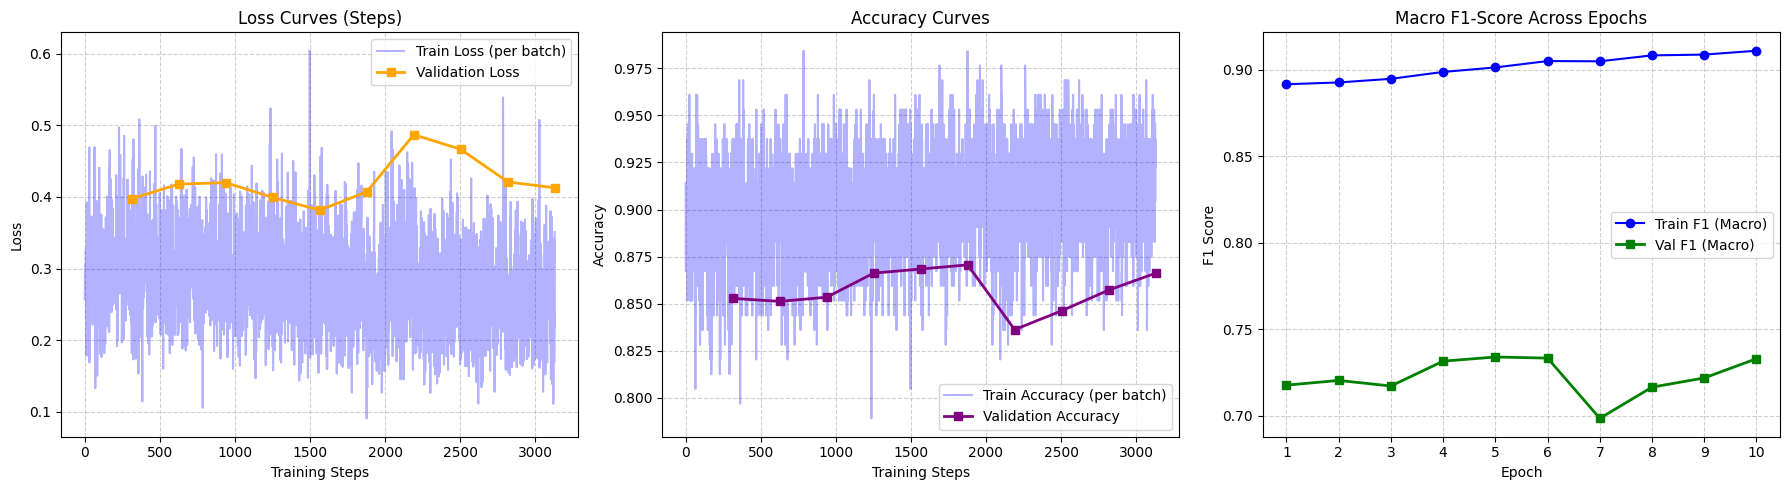

In [71]:
plot_all_metrics(metrics_4,'plots/LSTM_v4_training_metrics.png')

By increasing weight_decay, slightly poorer results were obtained on both the training and validation sets therefore, the initial configuration was kept as our final model.

# Evaluation on test dataset

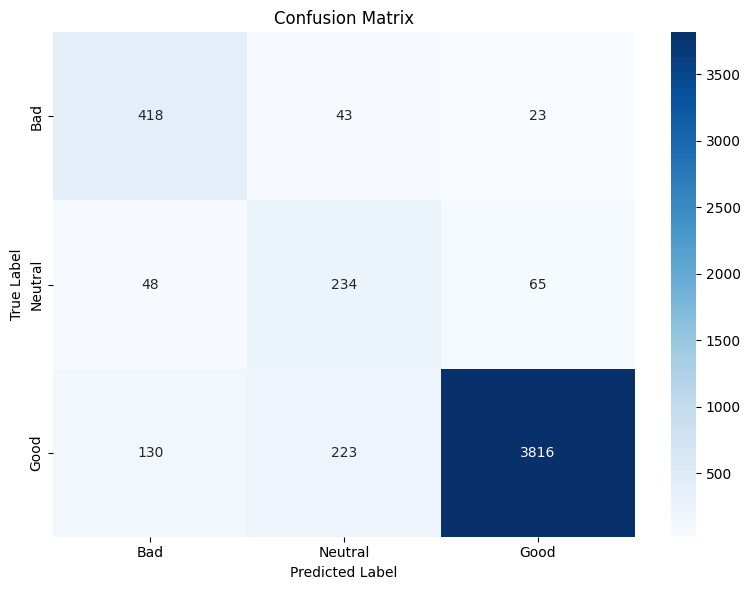


Classification Report:
              precision    recall  f1-score   support

         Bad       0.70      0.86      0.77       484
     Neutral       0.47      0.67      0.55       347
        Good       0.98      0.92      0.95      4169

    accuracy                           0.89      5000
   macro avg       0.72      0.82      0.76      5000
weighted avg       0.92      0.89      0.90      5000



In [83]:
final_test_report = evaluate_and_plot_confusion_matrix(model, val_loader, 'models/best_LSTM_v1.pth','plots/LSTM_v1_validation_confusion_matrix.png')

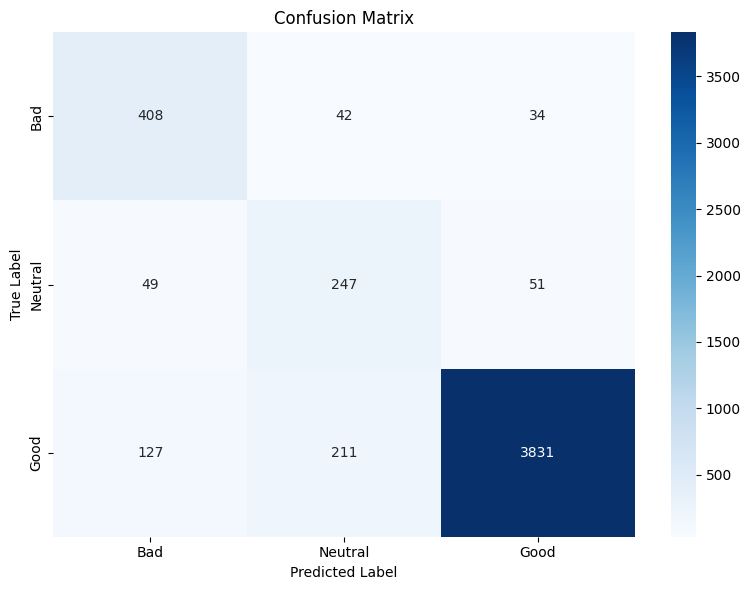


Classification Report:
              precision    recall  f1-score   support

         Bad       0.70      0.84      0.76       484
     Neutral       0.49      0.71      0.58       347
        Good       0.98      0.92      0.95      4169

    accuracy                           0.90      5000
   macro avg       0.72      0.82      0.76      5000
weighted avg       0.92      0.90      0.90      5000



In [82]:
final_test_report = evaluate_and_plot_confusion_matrix(model,test_loader, 'models/best_LSTM_v1.pth','plots/LSTM_final_test_confusion_matrix.png')

The model was tested on 5,000 unseen test samples and the results on the test set are very similar to our validation results. The model hits an accuracy of 0.90 with a macro F1-score of 0.76. Notably, the precision for the neutral class remains quite low (0.49 on the test set) in both cases, indicating that the model struggles to correctly identify and isolate neutral reviews without confusing them with other classes.

## Wrong predicted examples

In [83]:
model.load_state_dict(torch.load('models/best_LSTM_v1.pth', map_location=device))

model.eval()
all_preds = []
all_labels = []
 

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

In [84]:
errors = np.where(all_labels != all_preds)[0]

In [85]:
num_to_labels = {0: 'Bad', 1: 'Neutral', 2: 'Good'}
for idx in errors[:10]:
    text_rec = test_df.iloc[idx]['Text'] 
    
    print(text_rec)
    print(f"True class: {num_to_labels[all_labels[idx]]} | Predicted class: {num_to_labels[all_preds[idx]]}")
    print("-" * 50)

I was looking for 'apple crisps' but didn't want artificial ingredients or sugar added.  These fit the bill! Deliciously tart and semi- sweet.  Crisp enough but still a bit chewy...the best part?  My kids HATE them! Yum, Yum...more for me:-)
True class: Good | Predicted class: Bad
--------------------------------------------------
Sometimes these markers work great and sometimes not so much. I do think that they work better then anything I bought at the store.
True class: Neutral | Predicted class: Good
--------------------------------------------------
Breakfast Blend is mild and full favor.<br />Good for all day not just morning.
True class: Neutral | Predicted class: Good
--------------------------------------------------
These cookies are just da bomb and their calorie count is relatively low at the same time. Get these and you'll know why people in Belgium and France even eat these for breakfast or lunch.
True class: Good | Predicted class: Neutral
--------------------------------

Despite class balancing, the model still struggles because it gets confused by sarcasm and mixed sentiments within the same review. For instance, the model incorrectly classifies good review as bad because it reacts to isolated words like 'HATE' even when the rest of the sentence is playful and positive ('My kids HATE them... more for me').

A review stating 'I simply spread a bit on the carpet and let them frolic in it! Does not stain and easily removed with a vacuum!' was misclassified as neutral simply because it describes the practical interaction without using positive vocabulary.

The model struggles when negation words are used to praise a product rather than criticize it. For example, a glowing review praising clean ingredients ('That's the one and only ingredient in this oatmeal. No sugar. No salt. No preservatives... I love this oatmeal!') was misclassified as bad because the repeated presence of the word 'no' triggered a false negative association in the architecture, overriding the final positive concluding statement.

# Experiment 2: Training on an imbalanced dataset using class weights

In [25]:
train_df_imb = pd.read_csv('data/train_imbalanced.csv')

In [26]:
train_df_imb['Label'] = train_df_imb['Score'].map(label_map)

In [27]:
tokenized_train_imb = [clean_and_tokenize(t) for t in train_df_imb['Text']]

In [28]:
PAD_TOKEN = '<pad>'
UNK_TOKEN = '<unk>'

In [29]:
vocab_imb = build_vocab_from_iterator(tokenized_train_imb,min_freq=10,specials=[PAD_TOKEN,UNK_TOKEN],special_first=True)

In [30]:
vocab_imb.set_default_index(vocab_imb[UNK_TOKEN])

In [31]:
print('Vocabulary size:', len(vocab_imb))

Vocabulary size: 4652


In [33]:
EMBEDDING_DIM = 300

In [34]:
embedding_matrix_imb = torch.zeros((len(vocab_imb), EMBEDDING_DIM))
unmached_words_imb = []
matched_words_imb = 0
for word, idx in vocab_imb.get_stoi().items():
    if word == PAD_TOKEN or word == UNK_TOKEN:
        continue
    vector = word_embeddings.get(word)
    if vector is not None:
        embedding_matrix_imb[idx] = torch.tensor(vector)
        matched_words_imb += 1
    else:
        unmached_words_imb.append(word)

In [35]:
MAX_LEN = 50
BATCH_SIZE = 128

In [36]:
train_dataset_imb = TextDataset( tokenized_train_imb, train_df_imb['Label'], vocab_imb, max_len=MAX_LEN)
val_dataset_imb = TextDataset(tokenized_valid, val_df['Label'], vocab_imb, max_len=MAX_LEN)
test_dataset_imb = TextDataset(tokenized_test, test_df['Label'], vocab_imb, max_len=MAX_LEN)

In [37]:
train_loader_imb = DataLoader(train_dataset_imb, batch_size=BATCH_SIZE, shuffle=True, generator=g)
val_loader_imb = DataLoader(val_dataset_imb, batch_size=BATCH_SIZE, shuffle=False)
test_loader_imb = DataLoader(test_dataset_imb, batch_size=BATCH_SIZE, shuffle=False)

In [38]:
y_train_imb = train_df_imb['Label'].values

In [40]:
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_imb), y=y_train_imb)

In [41]:
class_weights

array([3.44619626, 4.79961603, 0.39976414])

The class weights are automatically computed based on the class distribution of the imbalanced training set. Minority classes receive higher weights to penalize misclassifications more severely, while the majority class receives a smaller weight to balance the overall loss contribution.

In [42]:
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

In [43]:
criterion_imb = nn.CrossEntropyLoss(weight=class_weights_tensor)

In [44]:
vocab_size = len(vocab_imb)  
EMBEDDING_DIM = 300      
HIDDEN_DIM = 128         
OUTPUT_DIM = 3           
N_LAYERS = 2 
DROPOUT = 0.2

model_imb = SentimentLSTM(embedding_matrix_imb,HIDDEN_DIM,OUTPUT_DIM,N_LAYERS,DROPOUT)

optimizer = optim.Adam(model_imb.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=1)

metrics_imb = train_model(
    model=model_imb, 
    optimizer=optimizer,
    scheduler = scheduler,
    train_loader=train_loader_imb,  
    valid_loader=val_loader_imb,  
    epochs=20,
    save_path='models/best_LSTM_imb_v1.pth',
    criterion=criterion_imb
)

[transformers] Disabling PyTorch because PyTorch >= 2.5 is required but found 2.3.0+cpu
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Epoch 1/20 [Train]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoha 1/20 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [1/20] | Train Loss: 0.8272 - Train Acc: 0.6966 | Val Loss: 0.4970 - Val Acc: 0.8328 - Val F1 (Macro): 0.6216


Epoch 2/20 [Train]:   0%|          | 0/313 [00:00<?, ?it/s]

...

Epoha 19/20 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [19/20] | Train Loss: 0.0133 - Train Acc: 0.9930 | Val Loss: 0.4844 - Val Acc: 0.9154 - Val F1 (Macro): 0.7722


Epoch 20/20 [Train]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoha 20/20 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [20/20] | Train Loss: 0.0102 - Train Acc: 0.9950 | Val Loss: 0.5165 - Val Acc: 0.9196 - Val F1 (Macro): 0.7779


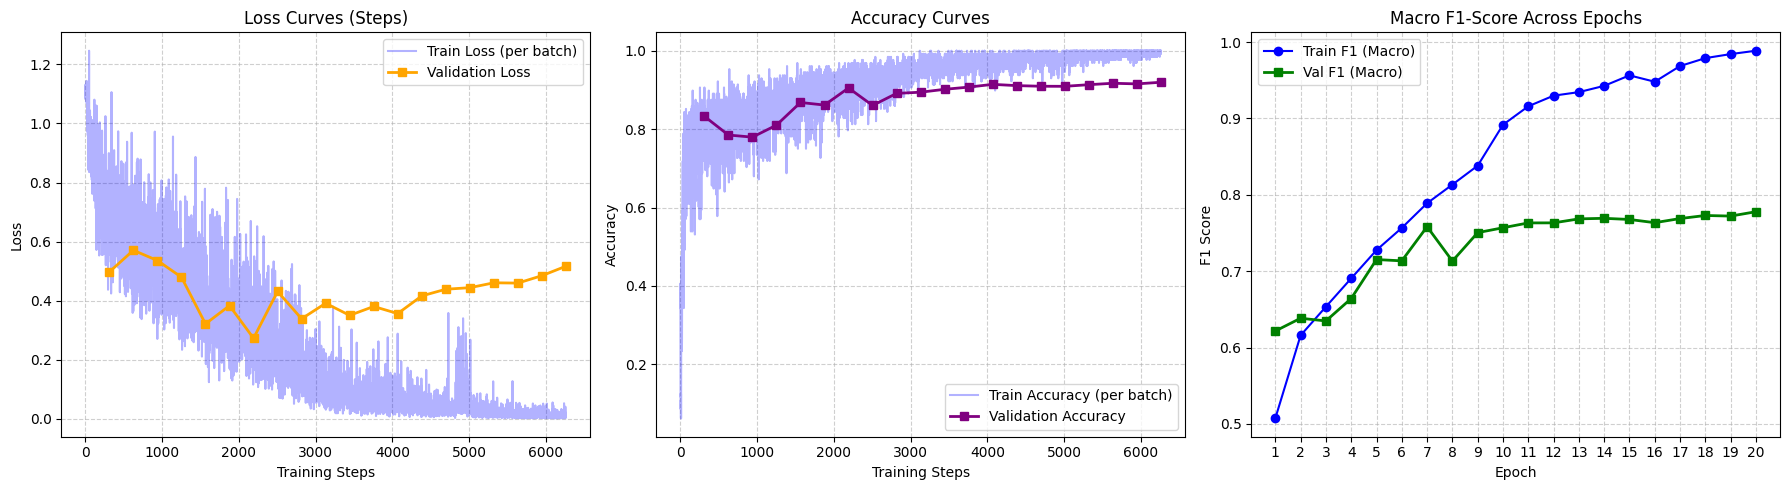

In [45]:
plot_all_metrics(metrics_imb,'plots/LSTM_v1_imb_training_metrics.png')

Analysis of the learning curves revealed that the model reaches its optimal point around epochs 7, after which divergence between the training and validation loss occurs. For the next step training is limited to 10 epochs.

In [46]:
vocab_size = len(vocab_imb)  
EMBEDDING_DIM = 300      
HIDDEN_DIM = 128         
OUTPUT_DIM = 3           
N_LAYERS = 2 
DROPOUT = 0.2

model_imb2 = SentimentLSTM(embedding_matrix_imb,HIDDEN_DIM,OUTPUT_DIM,N_LAYERS,DROPOUT)

optimizer2 = optim.Adam(model_imb2.parameters(), lr=0.001)
scheduler2 = optim.lr_scheduler.ReduceLROnPlateau(optimizer2, mode='max', factor=0.5, patience=1)

metrics_imb2 = train_model(
    model=model_imb2, 
    optimizer=optimizer2,
    scheduler = scheduler2,
    train_loader=train_loader_imb,  
    valid_loader=val_loader_imb,  
    epochs=10,
    save_path='models/best_LSTM_imb_v2.pth',
    criterion=criterion_imb
)

Epoch 1/10 [Train]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoha 1/10 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [1/10] | Train Loss: 0.8564 - Train Acc: 0.6746 | Val Loss: 0.6768 - Val Acc: 0.7076 - Val F1 (Macro): 0.5398


Epoch 2/10 [Train]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoha 2/10 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

...

Epoha 9/10 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [9/10] | Train Loss: 0.2287 - Train Acc: 0.9130 | Val Loss: 0.3076 - Val Acc: 0.8954 - Val F1 (Macro): 0.7508


Epoch 10/10 [Train]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoha 10/10 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [10/10] | Train Loss: 0.1771 - Train Acc: 0.9296 | Val Loss: 0.4049 - Val Acc: 0.8712 - Val F1 (Macro): 0.7290


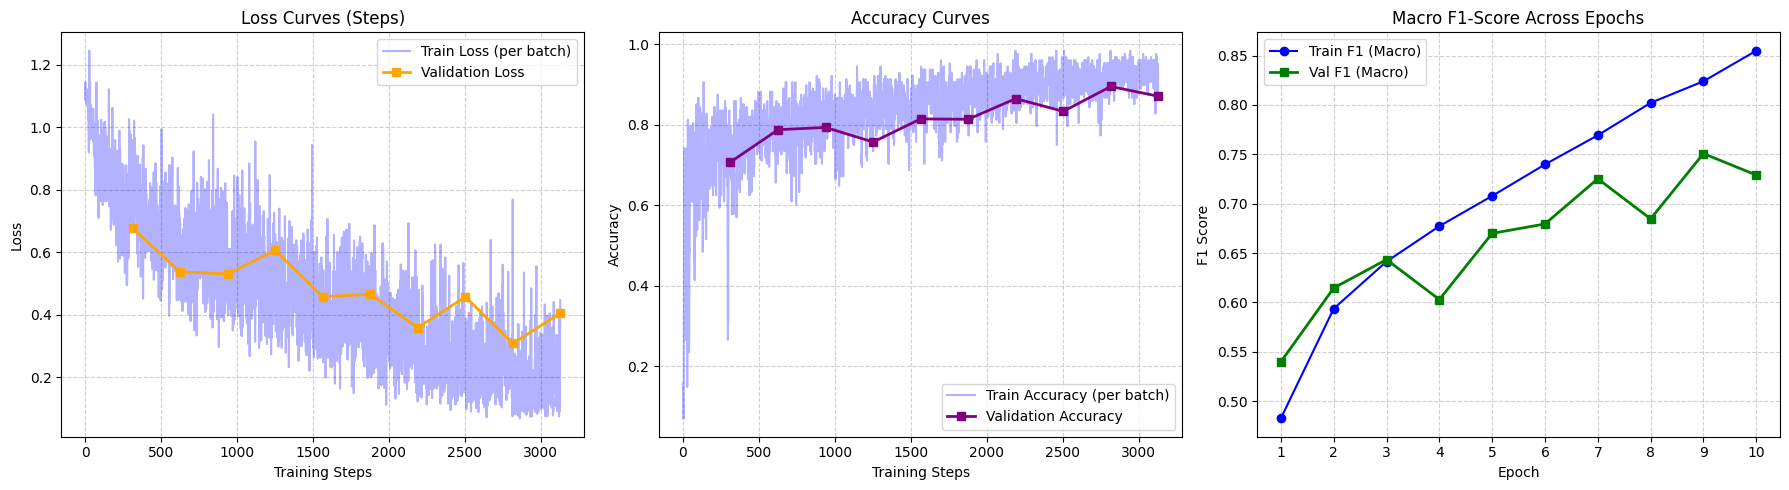

In [47]:
plot_all_metrics(metrics_imb2,'plots/LSTM_v2_imb_training_metrics.png')

Training was successfully limited to 10 epochs, which reduced overfitting. The validation loss remained stable up to epochs 7, and the best model was saved at epoch 9 with a peak Macro F1-score of approximately 0.75.

Fine-tuning was performed using the saved weights from the best model. To further control overfitting, regularization was increased by setting the dropout to 0.5, and the learning rate was reduced for more stable parameter updates.

In [48]:
vocab_size = len(vocab_imb)  
EMBEDDING_DIM = 300      
HIDDEN_DIM = 128         
OUTPUT_DIM = 3           
N_LAYERS = 2 
DROPOUT = 0.5
num_epochs = 10

model_imb3 = SentimentLSTM(embedding_matrix_imb,HIDDEN_DIM,OUTPUT_DIM,N_LAYERS,DROPOUT)
model_imb3.load_state_dict(torch.load('models/best_LSTM_imb_v2.pth', map_location=device))
model_imb3.to(device)

optimizer3 = optim.Adam(model_imb3.parameters(), lr=0.0005)
scheduler3 = optim.lr_scheduler.ReduceLROnPlateau(optimizer3, mode='max', factor=0.5, patience=2)

metrics_imb3 = train_model(
    model=model_imb3, 
    optimizer=optimizer3,
    scheduler = scheduler3,
    train_loader=train_loader_imb,  
    valid_loader=val_loader_imb,  
    epochs=num_epochs,
    save_path='models/best_LSTM_imb_v3.pth'
)

Epoch 1/10 [Train]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoha 1/10 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [1/10] | Train Loss: 0.1039 - Train Acc: 0.9605 | Val Loss: 0.2739 - Val Acc: 0.9246 - Val F1 (Macro): 0.7865


Epoch 2/10 [Train]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoha 2/10 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

...

Epoha 9/10 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [9/10] | Train Loss: 0.0096 - Train Acc: 0.9974 | Val Loss: 0.4922 - Val Acc: 0.9210 - Val F1 (Macro): 0.7871


Epoch 10/10 [Train]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoha 10/10 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [10/10] | Train Loss: 0.0050 - Train Acc: 0.9990 | Val Loss: 0.5125 - Val Acc: 0.9258 - Val F1 (Macro): 0.7948


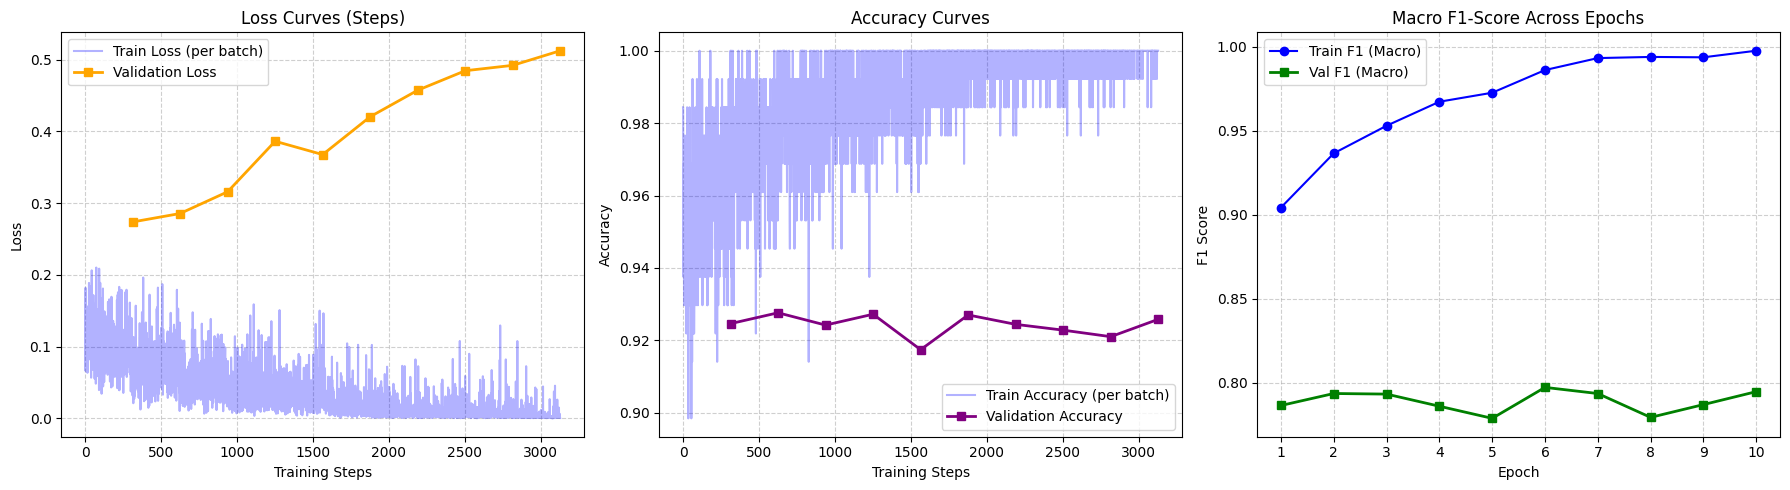

In [50]:
plot_all_metrics(metrics_imb3,'plots/LSTM_v3_imb_training_metrics.png')

Although a slight increase in the Macro F1 score was observed in later epochs, the loss curves clearly indicated persistent overfitting, with validation loss continuously rising. Consequently, this model checkpoint was rejected. Fine-tuning will be restarted from the previous stable version, incorporating weight decay regularization in the optimizer and restricting training to 5 epochs to prevent overfitting.

In [52]:
vocab_size = len(vocab_imb)  
EMBEDDING_DIM = 300     
HIDDEN_DIM = 128         
OUTPUT_DIM = 3           
N_LAYERS = 2 
DROPOUT = 0.5
num_epochs = 5  
model_imb4 = SentimentLSTM(embedding_matrix_imb, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, DROPOUT)

model_imb4.load_state_dict(torch.load('models/best_LSTM_imb_v2.pth', map_location=device))
model_imb4.to(device)

optimizer4 = optim.Adam(model_imb4.parameters(), lr=0.0005, weight_decay=1e-4)
scheduler4 = optim.lr_scheduler.ReduceLROnPlateau(optimizer4, mode='max', factor=0.5, patience=1)

metrics_imb4 = train_model(
    model=model_imb4, 
    optimizer=optimizer4,
    scheduler=scheduler4,
    train_loader=train_loader_imb,  
    valid_loader=val_loader_imb,  
    epochs=num_epochs,
    save_path='models/best_LSTM_imb_v4.pth'
)

Epoch 1/5 [Train]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoha 1/5 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [1/5] | Train Loss: 0.1054 - Train Acc: 0.9599 | Val Loss: 0.2637 - Val Acc: 0.9232 - Val F1 (Macro): 0.7866


Epoch 2/5 [Train]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoha 2/5 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

...

Epoha 4/5 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [4/5] | Train Loss: 0.0598 - Train Acc: 0.9795 | Val Loss: 0.3006 - Val Acc: 0.9260 - Val F1 (Macro): 0.7910


Epoch 5/5 [Train]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoha 5/5 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [5/5] | Train Loss: 0.0509 - Train Acc: 0.9833 | Val Loss: 0.3495 - Val Acc: 0.9198 - Val F1 (Macro): 0.7667


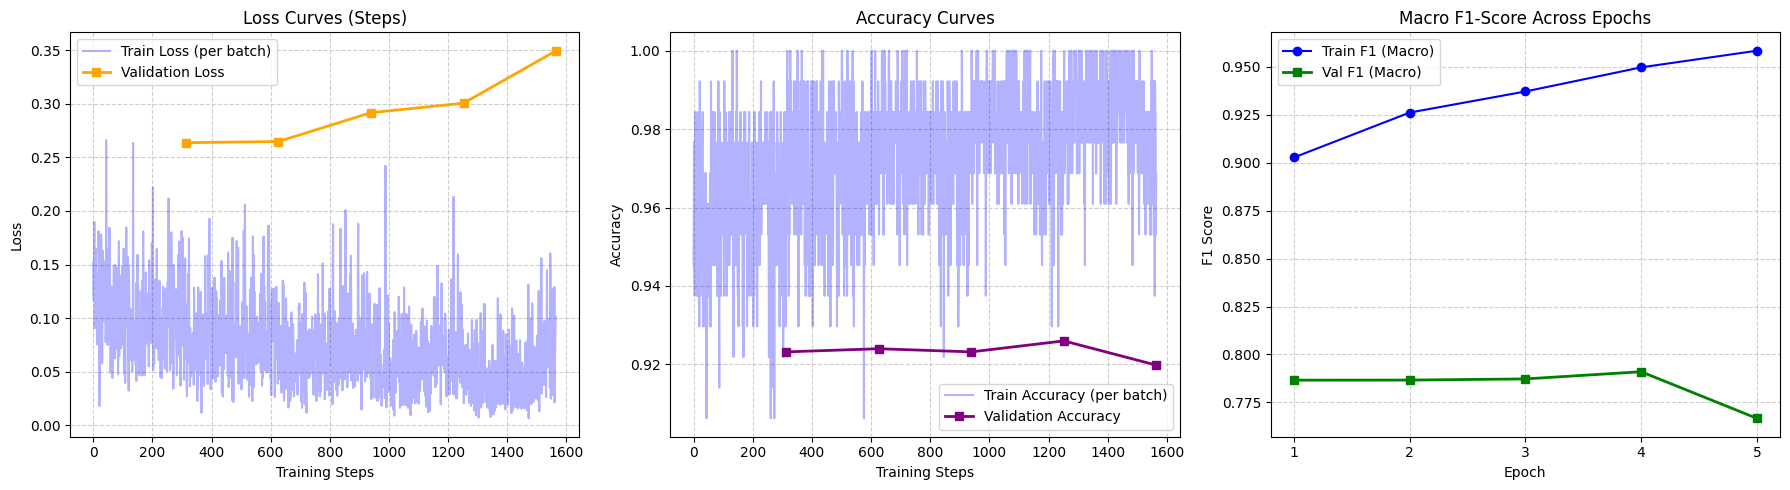

In [54]:
plot_all_metrics(metrics_imb4,'plots/LSTM_v4_imb_training_metrics.png')

Despite a slight increase in validation loss towards the end of training for version 4, applying weight decay regularization and limiting training to 5 epochs successfully mitigated severe overfitting compared to previous iterations.

In [55]:
vocab_size = len(vocab_imb)  
EMBEDDING_DIM = 300     
HIDDEN_DIM = 128         
OUTPUT_DIM = 3           
N_LAYERS = 2 
DROPOUT = 0.5
num_epochs = 5  

model_imb5 = SentimentLSTM(embedding_matrix_imb, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, DROPOUT)
model_imb5.load_state_dict(torch.load('models/best_LSTM_imb_v2.pth', map_location=device))
model_imb5.to(device)

optimizer5 = optim.Adam(model_imb5.parameters(), lr=0.0002, weight_decay=1e-3)
scheduler5 = optim.lr_scheduler.ReduceLROnPlateau(optimizer5, mode='max', factor=0.5, patience=1)

metrics_imb5 = train_model(
    model=model_imb5, 
    optimizer=optimizer5,
    scheduler=scheduler5,
    train_loader=train_loader_imb,  
    valid_loader=val_loader_imb,  
    epochs=num_epochs,
    save_path='models/best_LSTM_imb_v5.pth'
)

Epoch 1/5 [Train]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoha 1/5 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [1/5] | Train Loss: 0.1092 - Train Acc: 0.9592 | Val Loss: 0.2534 - Val Acc: 0.9154 - Val F1 (Macro): 0.7750


Epoch 2/5 [Train]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoha 2/5 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

...

Epoha 4/5 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [4/5] | Train Loss: 0.1125 - Train Acc: 0.9588 | Val Loss: 0.2550 - Val Acc: 0.9126 - Val F1 (Macro): 0.7682


Epoch 5/5 [Train]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoha 5/5 [Valid]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [5/5] | Train Loss: 0.1050 - Train Acc: 0.9627 | Val Loss: 0.2579 - Val Acc: 0.9224 - Val F1 (Macro): 0.7720


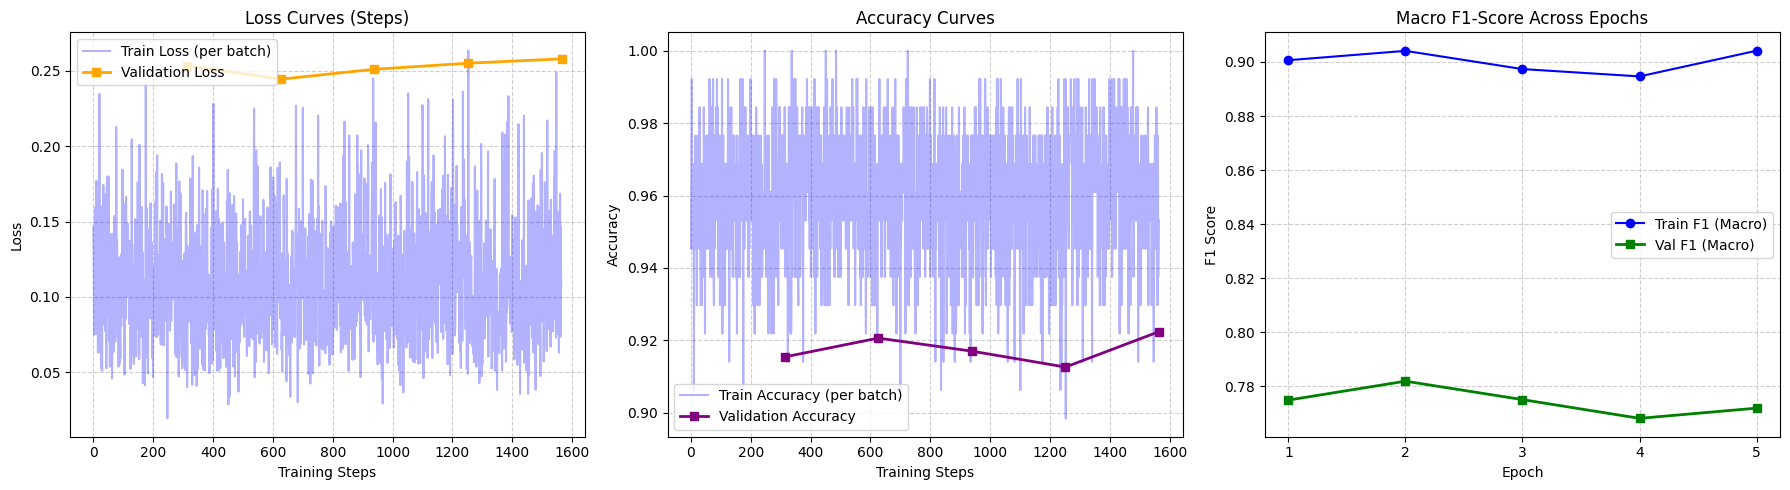

In [56]:
plot_all_metrics(metrics_imb5,'plots/LSTM_v5_imb_training_metrics.png')

Model model_imb5 was selected as the final choice because implementing stricter regularization (weight_decay of 1e-3 and a lower learning rate) ensures complete stability of the validation loss and successfully eliminates overfitting. Although the F1-score is marginally lower compared to previous iterations, this configuration guarantees consistency when generalizing to unseen data.

In [58]:
final_model_path = 'models/best_LSTM_imb_v5.pth'
model_final = SentimentLSTM(embedding_matrix_imb, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, DROPOUT)

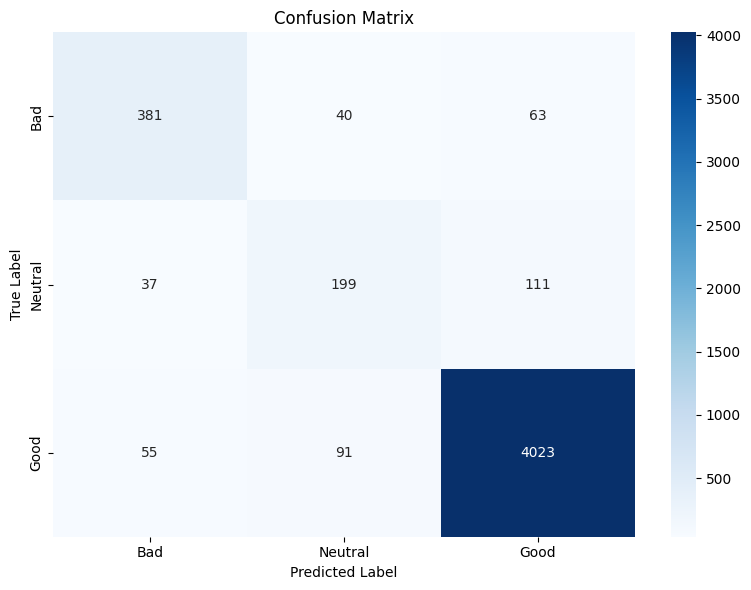


Classification Report:
              precision    recall  f1-score   support

         Bad       0.81      0.79      0.80       484
     Neutral       0.60      0.57      0.59       347
        Good       0.96      0.96      0.96      4169

    accuracy                           0.92      5000
   macro avg       0.79      0.78      0.78      5000
weighted avg       0.92      0.92      0.92      5000



In [62]:
final_valid_imb_report = evaluate_and_plot_confusion_matrix(model_final,val_loader_imb, final_model_path,'plots/LSTM_final_imb_valid_confusion_matrix.png')

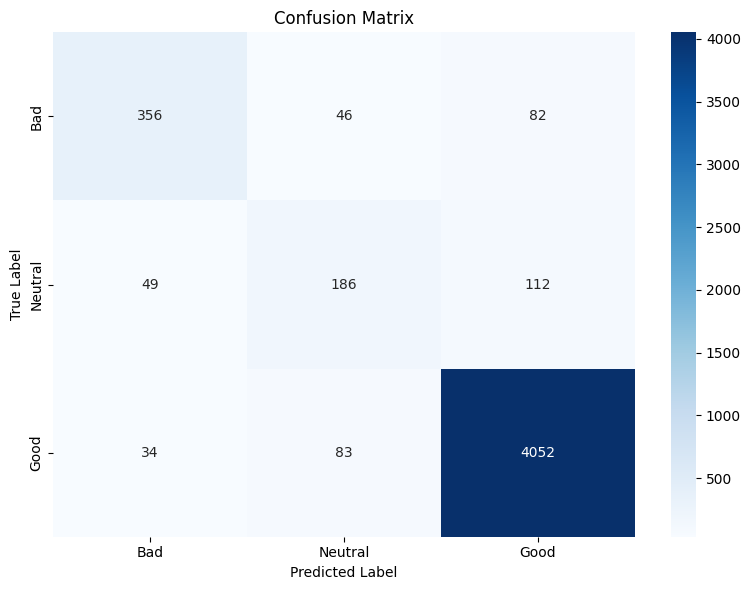


Classification Report:
              precision    recall  f1-score   support

         Bad       0.81      0.74      0.77       484
     Neutral       0.59      0.54      0.56       347
        Good       0.95      0.97      0.96      4169

    accuracy                           0.92      5000
   macro avg       0.79      0.75      0.77      5000
weighted avg       0.92      0.92      0.92      5000



In [63]:
final_test_imb_report = evaluate_and_plot_confusion_matrix(model_final,test_loader_imb, final_model_path,'plots/LSTM_final_imb_test_confusion_matrix.png')

The model was tested on 5000 unseen test samples, and the results on the test set were found to be very similar to the validation results. An accuracy of 0.92 with a macro F1-score of 0.77 was achieved. Notably, the precision and recall for the neutral class remained quite low in both cases, indicating that the model struggled to correctly identify and isolate neutral reviews.

In [97]:
df_bal = pd.DataFrame(final_test_report).transpose().drop(['accuracy', 'macro avg', 'weighted avg'])
df_imb = pd.DataFrame(final_test_imb_report).transpose().drop(['accuracy', 'macro avg', 'weighted avg'])

combined_df = pd.concat([df_bal, df_imb], axis=1, keys=['Balanced Model', 'Imbalanced Model'])
combined_df = combined_df.round(4)

display(combined_df)

Balanced Model                          Imbalanced Model          \
             precision  recall f1-score support        precision  recall   
Bad             0.7013  0.8636   0.7741   484.0           0.8109  0.7355   
Neutral         0.4680  0.6744   0.5525   347.0           0.5905  0.5360   
Good            0.9775  0.9153   0.9454  4169.0           0.9543  0.9719   

                          
        f1-score support  
Bad       0.7714   484.0  
Neutral   0.5619   347.0  
Good      0.9630  4169.0

In [98]:
global_metrics_df = pd.DataFrame({
    'Global Metric': ['Accuracy', 'Macro F1-Score'],
    'Balanced Model': [final_test_report['accuracy'], final_test_report['macro avg']['f1-score']],
    'Imbalanced Model': [final_test_imb_report['accuracy'],final_test_imb_report['macro avg']['f1-score']]
})

global_metrics_df = global_metrics_df.round(4)
display(global_metrics_df)

,Global Metric,Balanced Model,Imbalanced Model
0,Accuracy,0.8936,0.9188
1,Macro F1-Score,0.7573,0.7655


The precision of non-dominant classes is better in the model trained on the imbalanced training set that was balanced in a certain way using class weights during the loss function calculation, whereas the recall of non-dominant classes is slightly better in the model that used balanced data for training. Although the model that used imbalanced training dataset used class weights in the loss function to compensate for underrepresented classes, it still achieves a higher recall for good reviews (and lower precision). This happens because the model still encounters the natural, dominant distribution of good reviews in its batches during training, making it much more confident in recognizing them compared to the model trained on fully balanced data.